# Densities

In [88]:
import sys
sys.path.insert(0, '../../src/')

import numpy as np
import matplotlib.pyplot as plt
import pickle as pkl
import tensorflow as tf


from spectrum import channel_spectrum, complex_spacing_ratio, Spectrum, coat_spectrum, spectrum_to_angular, spectrum_to_radial
from analysis import *

#np.set_printoptions(threshold=sys.maxsize)
np.set_printoptions(precision=4)

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

In [89]:
import numpy as np
import matplotlib.pyplot as plt

c_min = 0
c_max = 80

def plot_spectrum(spectrum, filename, x_ticks=True, y_ticks=True, label=None):
    spectrum_coat = coat_spectrum(spectrum, sigma=0.02)

    norm = np.sum(spectrum_coat) * 1/10000
    csr_density = spectrum_coat / norm
    print(np.max(csr_density))

    fig, ax = plt.subplots(figsize=(5, 5))
    fig.tight_layout()

    # draw the heatmap and grab the AxesImage
    im = ax.imshow(
        csr_density,
        interpolation="gaussian",
        extent=(-1, 1, -1, 1),
        cmap="RdBu_r",
    )
    # set color limits on the image itself
    im.set_clim(0, c_max)

    # draw the label in the top‐left, in axes coords:
    if label is not None:
        ax.text(
            0.02, 0.98,         # 2% from left, 98% from bottom
            label,
            transform=ax.transAxes,
            va="top",           # align text top
            ha="left",          # align text left
            fontsize=20,
            color="white",      # or choose a contrasting color
            bbox=dict(
                facecolor="black", 
                alpha=0.5,       # translucent background
                pad=2
            )
        )

    # ticks & labels
    if x_ticks:
        ax.set_xlabel("Re (z)", fontsize=24)
        ax.set_xticks(np.arange(-1, 1.1, 0.5))
        ax.tick_params(axis="x", labelsize=24)
    else:
        ax.set_xticks([])

    if y_ticks:
        ax.set_ylabel("Im (z)", fontsize=24)
        ax.set_yticks(np.arange(-1, 1.1, 0.5))
        ax.tick_params(axis="y", labelsize=24)
    else:
        ax.set_yticks([])

    # save & show
    outname = filename.replace(".large", ".svg").replace("data", "figures")
    plt.savefig(outname, bbox_inches="tight")
    plt.show()

## No Coupling

In [90]:
r_list_noCoupling = []
r_list_weakCoupling = []
r_list_strongCoupling = []

r_std_noCoupling = []
r_std_weakCoupling = []
r_std_strongCoupling = []

56.58693741857738


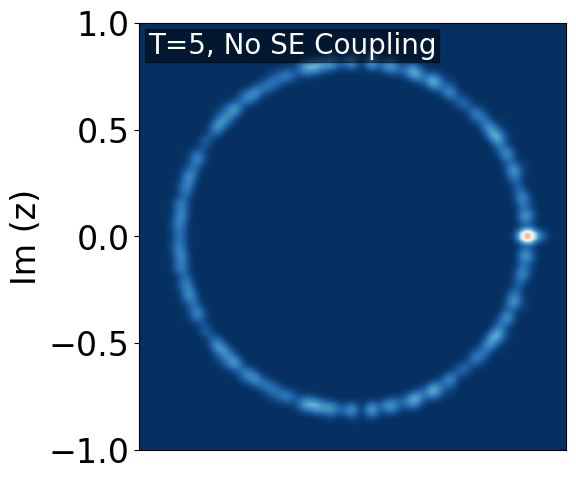

0.8228797794479964
10


In [91]:
n = 4

model_list = pkl.load(open(f'models/integrable_baseline_model_{n}_L=5.model', 'rb'))

loss_list = []
spectrum_list = []
csr_integrable_list = []
for model in model_list:
    loss = model.logger.loss_list[0][-1]
    loss_list.append(loss)

    channel = model.channel
    spectrum = channel_spectrum(channel, keep_unity=False)

    spectrum_list.append(spectrum)

spectrum = Spectrum(spectrum_list)

plot_spectrum(spectrum, 'figures/integrable_spectrum_L=5.svg', x_ticks=False, y_ticks=True, label="T=5, No SE Coupling")

r = spectrum_to_radial(spectrum)
r_mean = np.mean(r)
r_std = np.std(r)

print(r_mean)

print(len(model_list))

r_list_noCoupling.append(r_mean)
r_std_noCoupling.append(r_std)

41.07407606597967


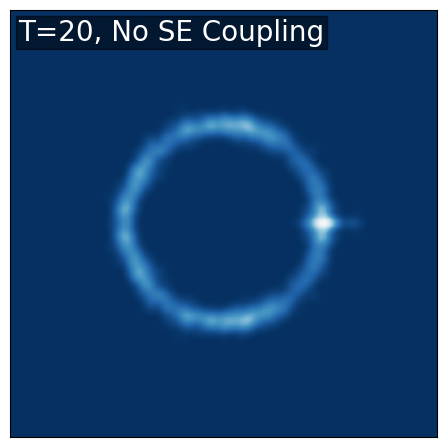

0.46782457342943445


In [92]:
n = 4

model_list = pkl.load(open(f'models/integrable_baseline_model_{n}_L=20.model', 'rb'))

loss_list = []
spectrum_list = []
csr_integrable_list = []
for model in model_list:
    loss = model.logger.loss_list[0][-1]
    loss_list.append(loss)

    channel = model.channel
    spectrum = channel_spectrum(channel, keep_unity=False)

    spectrum_list.append(spectrum)

spectrum = Spectrum(spectrum_list)

plot_spectrum(spectrum, 'figures/integrable_spectrum_L=20.svg', x_ticks=False, y_ticks=False, label="T=20, No SE Coupling")

r = spectrum_to_radial(spectrum)
r_mean = np.mean(r)
r_std = np.std(r)

print(r_mean)

r_list_noCoupling.append(r_mean)
r_std_noCoupling.append(r_std)

54.28847919953362


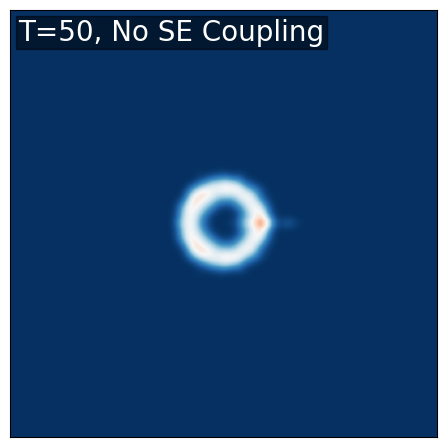

0.1657845040255153


In [93]:
n = 4

model_list = pkl.load(open(f'models/integrable_baseline_model_{n}_L=50.model', 'rb'))

loss_list = []
spectrum_list = []
csr_integrable_list = []
for model in model_list:
    loss = model.logger.loss_list[0][-1]
    loss_list.append(loss)

    channel = model.channel
    spectrum = channel_spectrum(channel, keep_unity=False)

    spectrum_list.append(spectrum)

spectrum = Spectrum(spectrum_list)
plot_spectrum(spectrum, 'figures/integrable_spectrum_L=50.svg', x_ticks=False, y_ticks=False, label="T=50, No SE Coupling")

r = spectrum_to_radial(spectrum)
r_mean = np.mean(r)
r_std = np.std(r)

print(r_mean)

r_list_noCoupling.append(r_mean)
r_std_noCoupling.append(r_std)

## Weak

32.28333989046043


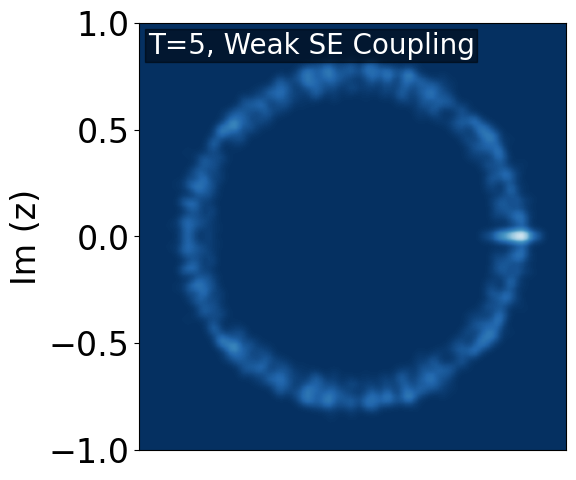

0.7632813838183244


In [94]:
n = 4

model_list = pkl.load(open(f'models/integrable_intermediate_model_{n}_L=5.model', 'rb'))

loss_list = []
spectrum_list = []
csr_integrable_list = []
for model in model_list:
    loss = model.logger.loss_list[0][-1]
    loss_list.append(loss)

    channel = model.channel
    spectrum = channel_spectrum(channel, keep_unity=False)

    spectrum_list.append(spectrum)

spectrum = Spectrum(spectrum_list)
plot_spectrum(spectrum, 'figures/integrable_intermediate_spectrum_L=5.svg', x_ticks=False, y_ticks=True, label="T=5, Weak SE Coupling")

r = spectrum_to_radial(spectrum)
r_mean = np.mean(r)
r_std = np.std(r)

print(r_mean)

r_list_weakCoupling.append(r_mean)
r_std_weakCoupling.append(r_std)

19.950646733906492


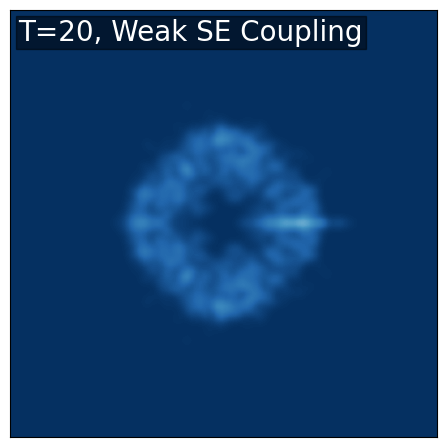

0.33254110280720606


In [95]:
n = 4

model_list = pkl.load(open(f'models/integrable_intermediate_model_{n}_L=20.model', 'rb'))

loss_list = []
spectrum_list = []
csr_integrable_list = []
for model in model_list:
    loss = model.logger.loss_list[0][-1]
    loss_list.append(loss)

    channel = model.channel
    spectrum = channel_spectrum(channel, keep_unity=False)

    spectrum_list.append(spectrum)

spectrum = Spectrum(spectrum_list)
plot_spectrum(spectrum, 'figures/integrable_intermediate_spectrum_L=20.svg', x_ticks=False, y_ticks=False, label="T=20, Weak SE Coupling")

r = spectrum_to_radial(spectrum)
r_mean = np.mean(r)
r_std = np.std(r)

print(r_mean)

r_list_weakCoupling.append(r_mean)
r_std_weakCoupling.append(r_std)

86.94955277095025


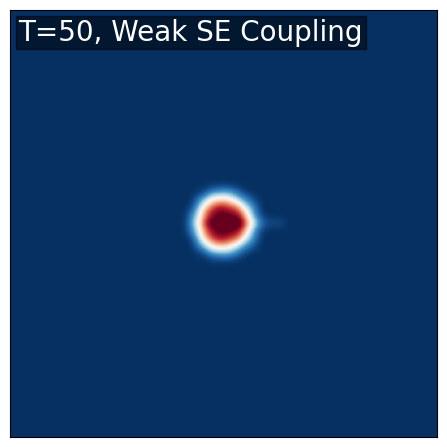

0.09067863615423613


In [96]:
n = 4

model_list = pkl.load(open(f'models/integrable_intermediate_model_{n}_L=50.model', 'rb'))

loss_list = []
spectrum_list = []
csr_integrable_list = []
for model in model_list:
    loss = model.logger.loss_list[0][-1]
    loss_list.append(loss)

    channel = model.channel
    spectrum = channel_spectrum(channel, keep_unity=False)

    spectrum_list.append(spectrum)

spectrum = Spectrum(spectrum_list)
plot_spectrum(spectrum, 'figures/integrable_intermediate_spectrum_L=50.svg', x_ticks=False, y_ticks=False, label="T=50, Weak SE Coupling")

r = spectrum_to_radial(spectrum)
r_mean = np.mean(r)
r_std = np.std(r)

print(r_mean)

r_list_weakCoupling.append(r_mean)
r_std_weakCoupling.append(r_std)

## Strong

12.493939525096994


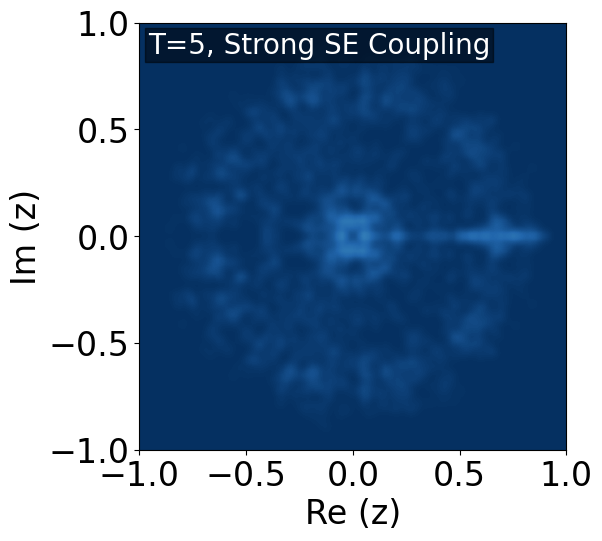

0.5162673081858641


In [97]:
n = 4

model_list = pkl.load(open(f'../fitting_maps/models/integrable_model_{n}_L=5.model', 'rb'))

loss_list = []
spectrum_list = []
csr_integrable_list = []
for model in model_list:
    loss = model.logger.loss_list[0][-1]
    loss_list.append(loss)

    channel = model.channel
    spectrum = channel_spectrum(channel, keep_unity=False)

    spectrum_list.append(spectrum)

spectrum = Spectrum(spectrum_list)
plot_spectrum(spectrum, 'figures/integrable_strong_spectrum_L=5.svg', x_ticks=True, y_ticks=True, label="T=5, Strong SE Coupling")

r = spectrum_to_radial(spectrum)
r_mean = np.mean(r)
r_std = np.std(r)

print(r_mean)

r_list_strongCoupling.append(r_mean)
r_std_strongCoupling.append(r_std)

17.754760628061298


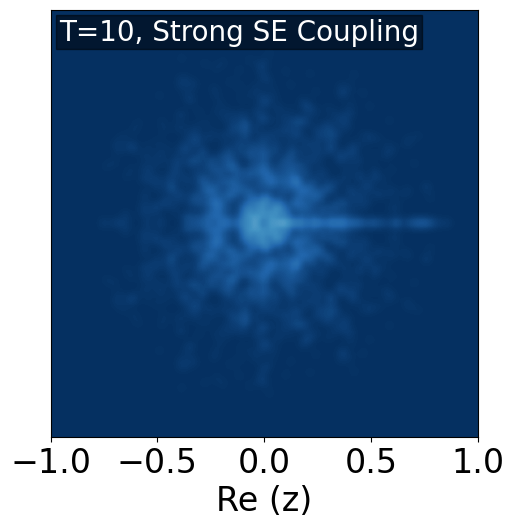

0.33111653647989886


In [98]:
n = 4

model_list = pkl.load(open(f'../fitting_maps/models/integrable_model_{n}_L=10.model', 'rb'))

loss_list = []
spectrum_list = []
csr_integrable_list = []
for model in model_list:
    loss = model.logger.loss_list[0][-1]
    loss_list.append(loss)

    channel = model.channel
    spectrum = channel_spectrum(channel, keep_unity=False)

    spectrum_list.append(spectrum)

spectrum = Spectrum(spectrum_list)
plot_spectrum(spectrum, 'figures/integrable_strong_spectrum_L=10.svg', x_ticks=True, y_ticks=False, label="T=10, Strong SE Coupling")

r = spectrum_to_radial(spectrum)
r_mean = np.mean(r)
r_std = np.std(r)

print(r_mean)

r_list_strongCoupling.append(r_mean)
r_std_strongCoupling.append(r_std)

81.62562434364759


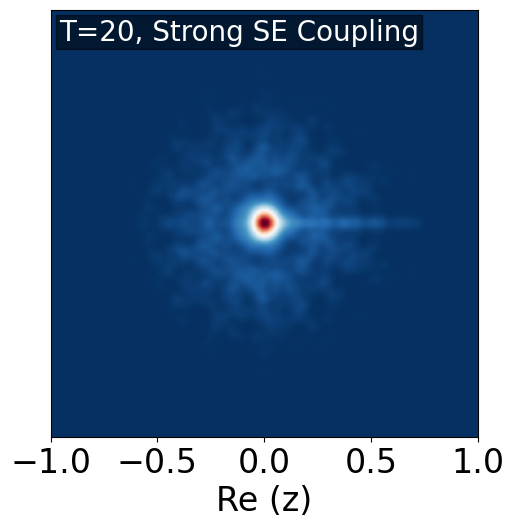

0.24388813998946976


In [99]:
n = 4

model_list = pkl.load(open(f'../fitting_maps/models/integrable_model_{n}_L=20_reorder.model', 'rb'))

loss_list = []
spectrum_list = []
csr_integrable_list = []
for model in model_list:
    loss = model.logger.loss_list[0][-1]
    loss_list.append(loss)

    channel = model.channel
    spectrum = channel_spectrum(channel, keep_unity=False)

    spectrum_list.append(spectrum)

spectrum = Spectrum(spectrum_list)
plot_spectrum(spectrum, 'figures/integrable_strong_spectrum_L=20.svg', x_ticks=True, y_ticks=False, label="T=20, Strong SE Coupling")

r = spectrum_to_radial(spectrum)
r_mean = np.mean(r)
r_std = np.std(r)

print(r_mean)

r_list_strongCoupling.append(r_mean)
r_std_strongCoupling.append(r_std)

26.034934456583365


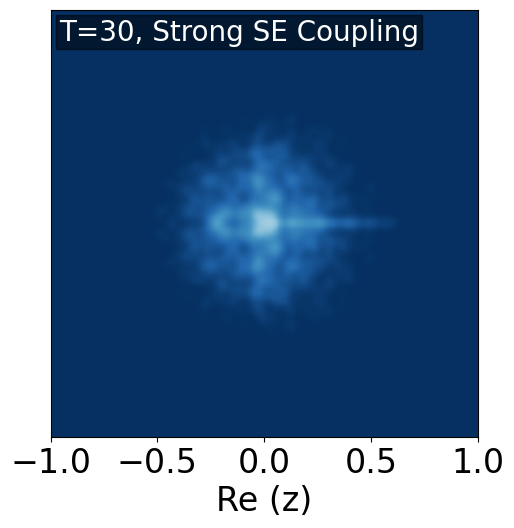

0.23646379969833042


In [100]:
n = 4

model_list = pkl.load(open(f'../fitting_maps/models/integrable_model_{n}_L=30_reorder.model', 'rb'))

loss_list = []
spectrum_list = []
csr_integrable_list = []
for model in model_list:
    loss = model.logger.loss_list[0][-1]
    loss_list.append(loss)

    channel = model.channel
    spectrum = channel_spectrum(channel, keep_unity=False)

    spectrum_list.append(spectrum)

spectrum = Spectrum(spectrum_list)
plot_spectrum(spectrum, 'figures/integrable_strong_spectrum_L=30.svg', x_ticks=True, y_ticks=False, label="T=30, Strong SE Coupling")

r = spectrum_to_radial(spectrum)
r_mean = np.mean(r)
r_std = np.std(r)

print(r_mean)

r_list_strongCoupling.append(r_mean)
r_std_strongCoupling.append(r_std)

74.35647955210511


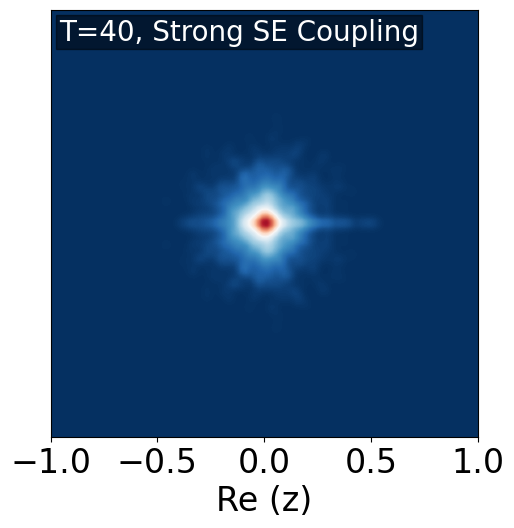

0.15599722358594814


In [101]:
n = 4

model_list = pkl.load(open(f'../fitting_maps/models/integrable_model_{n}_L=40_reorder.model', 'rb'))

loss_list = []
spectrum_list = []
csr_integrable_list = []
for model in model_list:
    loss = model.logger.loss_list[0][-1]
    loss_list.append(loss)

    channel = model.channel
    spectrum = channel_spectrum(channel, keep_unity=False)

    spectrum_list.append(spectrum)

spectrum = Spectrum(spectrum_list)
plot_spectrum(spectrum, 'figures/integrable_strong_spectrum_L=40.svg', x_ticks=True, y_ticks=False, label="T=40, Strong SE Coupling")

r = spectrum_to_radial(spectrum)
r_mean = np.mean(r)
r_std = np.std(r)

print(r_mean)

r_list_strongCoupling.append(r_mean)
r_std_strongCoupling.append(r_std)

71.89290994402445


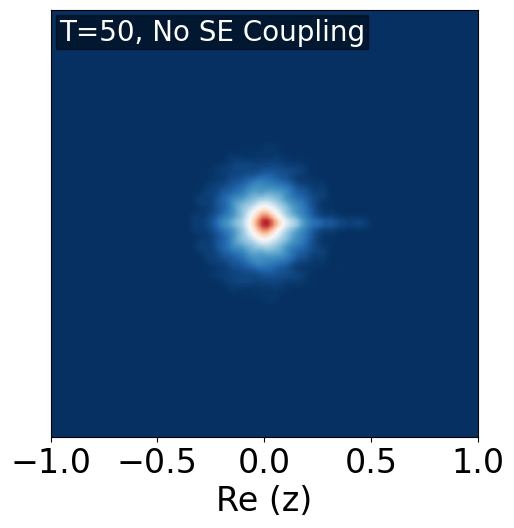

0.14199514716662878


In [102]:
n = 4

model_list = pkl.load(open(f'../fitting_maps/models/integrable_model_{n}_L=50_reorder.model', 'rb'))

loss_list = []
spectrum_list = []
csr_integrable_list = []
for model in model_list:
    loss = model.logger.loss_list[0][-1]
    loss_list.append(loss)

    channel = model.channel
    spectrum = channel_spectrum(channel, keep_unity=False)

    spectrum_list.append(spectrum)

spectrum = Spectrum(spectrum_list)
plot_spectrum(spectrum, 'figures/integrable_strong_spectrum_L=50.svg', x_ticks=True, y_ticks=False, label="T=50, No SE Coupling")

r = spectrum_to_radial(spectrum)
r_mean = np.mean(r)
r_std = np.std(r)

print(r_mean)

r_list_strongCoupling.append(r_mean)
r_std_strongCoupling.append(r_std)

In [103]:
import matplotlib.pyplot as plt
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import Normalize
from matplotlib.cm import get_cmap

# 1. Create a figure and one axes for the colorbar
fig, ax = plt.subplots(figsize=(0.5, 6))  # tall & skinny

# 2. Define your colormap and data range
cmap = get_cmap("RdBu_r")
norm = Normalize(vmin=c_min, vmax=c_max)

# 3. Draw a vertical colorbar in that axes
cb = ColorbarBase(ax,
                  cmap=cmap,
                  norm=norm,
                  orientation="vertical")
cb.set_label("probability", fontsize=14)

# 4. (Optional) Tweak tick font sizes
ax.tick_params(labelsize=12)

# 5. Save just the colorbar
plt.savefig("figures/colorbar.svg", bbox_inches="tight")
plt.close(fig)

/tmp/ipykernel_521724/1700418182.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("RdBu_r")


In [104]:
r_err_strongCoupling = np.array(r_std_strongCoupling)/np.sqrt(10)
r_err_weakCoupling = np.array(r_std_weakCoupling)/np.sqrt(10)
r_err_noCoupling = np.array(r_std_noCoupling)/np.sqrt(10)


print(len(model_list))

10


## Dissipation Metric

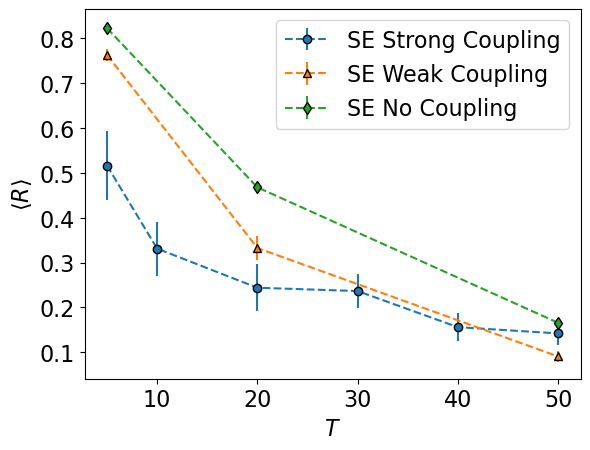

In [105]:
plt.errorbar([5, 10, 20, 30, 40, 50], r_list_strongCoupling, yerr=r_err_strongCoupling, fmt="o--", mec="k", label="SE Strong Coupling")
plt.errorbar([5, 20, 50], r_list_weakCoupling, yerr=r_err_weakCoupling, fmt="^--", mec="k", label="SE Weak Coupling")
plt.errorbar([5, 20, 50], r_list_noCoupling, yerr=r_err_noCoupling, fmt="d--", mec="k", label="SE No Coupling")
plt.xlabel("$T$", fontsize=16)
plt.ylabel(r"$\langle R \rangle$", fontsize=16)
plt.legend(fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.savefig('figures/figure_of_merit.pdf')
plt.show()